<a href="https://colab.research.google.com/github/iShubhamRajput/alfido-zomato-task/blob/main/zomato_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Zomato Dataset Analysis

**Internship Task:** Zomato Dataset Analysis  
**Dataset:** `bhanupratapbiswas/zomato` from Kaggle

Goal: analyze restaurant and review data to extract insights on ratings, cuisines, location preferences, price, and factors affecting ratings.

## 1. Install and Import Libraries

In [ ]:
# Run this cell first in Google Colab or Jupyter.\n# If a package is already installed, this is safe.
import sys
!{sys.executable} -m pip install -q pandas numpy matplotlib seaborn wordcloud kaggle
from pathlib import Path
import os
import re
import zipfile
import subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titleweight'] = 'bold'
pd.set_option('display.max_columns', 50)

## 2. Download the Kaggle Dataset\n\nIf running in Google Colab, upload your `kaggle.json` API key when asked. You can create it from Kaggle: Account -> API -> Create New Token.

In [ ]:
from pathlib import Path
import pandas as pd

# Use uploaded CSV directly if you uploaded zomato.csv in Colab
csv_files = [Path("data/zomato.csv")]

df = pd.read_csv(csv_files[0], on_bad_lines="skip")

print("Shape:", df.shape)
df.head()

Shape: (56252, 13)


,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),listed_in(type)
0,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,Buffet
1,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,Buffet
2,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,Buffet
3,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,Buffet
4,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,Buffet


## 3. Load and Inspect Data

In [ ]:
csv_path = csv_files[0]
df = pd.read_csv(csv_path, on_bad_lines='skip')

print('Shape:', df.shape)
display(df.head())
display(df.info())

Shape: (56252, 13)


,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),listed_in(type)
0,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,Buffet
1,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,Buffet
2,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,Buffet
3,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,Buffet
4,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,Buffet


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56252 entries, 0 to 56251
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   address                      56235 non-null  object
 1   name                         56236 non-null  object
 2   online_order                 56233 non-null  object
 3   book_table                   56194 non-null  object
 4   rate                         48414 non-null  object
 5   votes                        56174 non-null  object
 6   phone                        54956 non-null  object
 7   location                     56126 non-null  object
 8   rest_type                    55914 non-null  object
 9   dish_liked                   28027 non-null  object
 10  cuisines                     56049 non-null  object
 11  approx_cost(for two people)  55731 non-null  object
 12  listed_in(type)              51642 non-null  object
dtypes: object(13)
memory usage: 5.6

None

In [ ]:
missing = df.isna().sum().sort_values(ascending=False)
display(missing)

,0
dish_liked,28225
rate,7838
listed_in(type),4610
phone,1296
approx_cost(for two people),521
rest_type,338
cuisines,203
location,126
votes,78
book_table,58


## 4. Data Cleaning

In [ ]:
clean = df.copy()

# Standardize text columns
for col in clean.select_dtypes(include='object').columns:
    clean[col] = clean[col].astype(str).str.strip()
    clean[col] = clean[col].replace({'nan': np.nan, 'None': np.nan, '': np.nan})

# Convert ratings like '4.1/5' into 4.1. NEW and '-' become NaN.
clean['rating'] = (
    clean['rate']
    .astype(str)
    .str.extract(r'(\d+(?:\.\d+)?)')[0] # Fixed regex
    .astype(float)
)
clean.loc[(clean['rating'] < 0) | (clean['rating'] > 5), 'rating'] = np.nan

# Convert cost for two people into numeric rupee amount.
cost_col = 'approx_cost(for two people)'
clean['cost_for_two'] = (
    clean[cost_col]
    .astype(str)
    .str.replace(',', '', regex=False)
    .str.extract(r'(\d+(?:\.\d+)?)')[0] # Fixed regex
    .astype(float)
)

clean['votes'] = pd.to_numeric(clean['votes'], errors='coerce')

# Keep valid Yes/No category rows for relationship analysis.
valid = clean[
    clean['rating'].notna()
    & clean['online_order'].isin(['Yes', 'No'])
    & clean['book_table'].isin(['Yes', 'No'])
].copy()

print('Original rows:', len(df))
print('Clean valid rows:', len(valid))
print('Average rating:', round(valid['rating'].mean(), 2))
print('Average cost for two:', round(valid['cost_for_two'].mean(), 0))
display(valid.head())

Original rows: 56252
Clean valid rows: 41665
Average rating: 3.7
Average cost for two: 603.0


,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),listed_in(type),rating,cost_for_two
0,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775.0,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,Buffet,4.1,800.0
1,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787.0,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,Buffet,4.1,800.0
2,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918.0,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,Buffet,3.8,800.0
3,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88.0,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,Buffet,3.7,300.0
4,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166.0,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,Buffet,3.8,600.0


In [ ]:
cleaning_summary = pd.DataFrame({
    'missing_before': df.isna().sum(),
    'missing_after_basic_cleaning': clean.isna().sum()
}).sort_values('missing_after_basic_cleaning', ascending=False)
display(cleaning_summary)

,missing_before,missing_after_basic_cleaning
cost_for_two,NaN,56252
rating,NaN,56252
dish_liked,28225.0,28225
rate,7838.0,7839
listed_in(type),4610.0,4610
votes,78.0,4535
phone,1296.0,1296
approx_cost(for two people),521.0,521
rest_type,338.0,338
cuisines,203.0,203


## 5. Visualizations

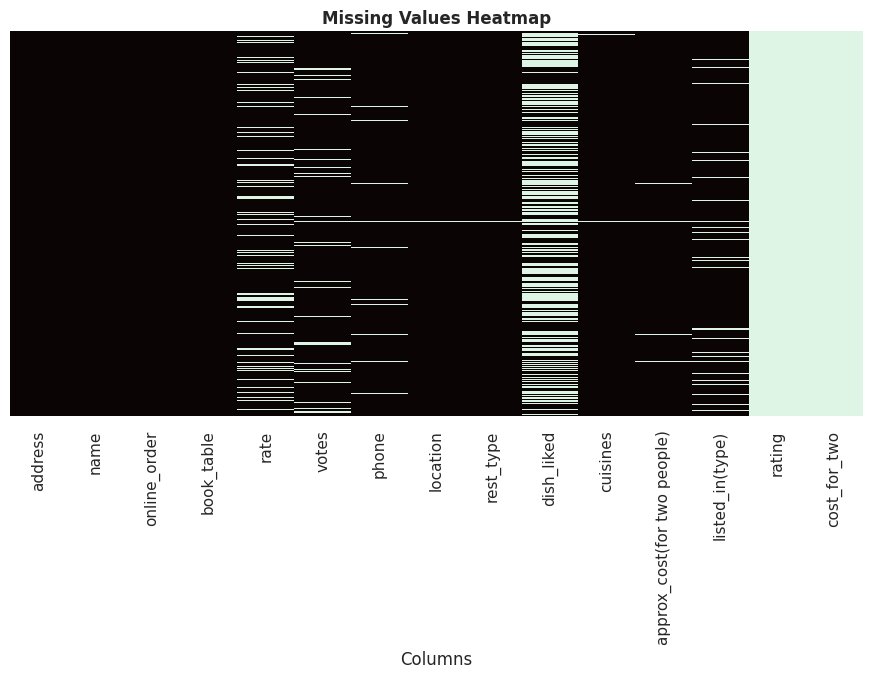

In [ ]:
plt.figure(figsize=(11, 5))
sns.heatmap(clean.isna(), cbar=False, yticklabels=False, cmap='mako')
plt.title('Missing Values Heatmap')
plt.xlabel('Columns')
plt.show()

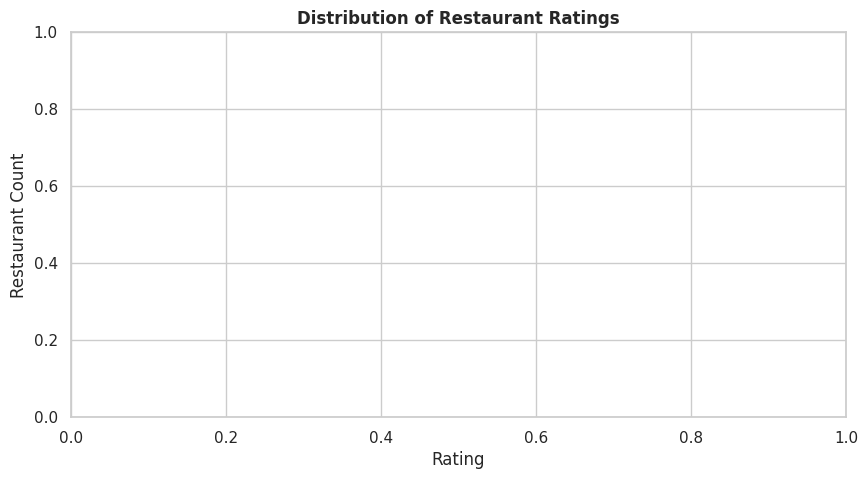

In [ ]:
sns.histplot(valid['rating'], bins=20, kde=True, color='#2a9d8f')
plt.title('Distribution of Restaurant Ratings')
plt.xlabel('Rating')
plt.ylabel('Restaurant Count')
plt.show()

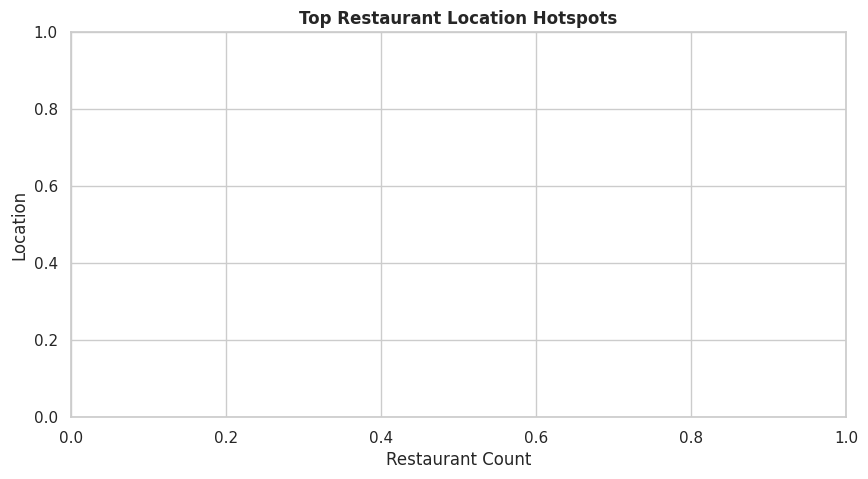

In [ ]:
top_locations = valid['location'].value_counts().head(12)
sns.barplot(x=top_locations.values, y=top_locations.index, palette='viridis')
plt.title('Top Restaurant Location Hotspots')
plt.xlabel('Restaurant Count')
plt.ylabel('Location')
plt.show()

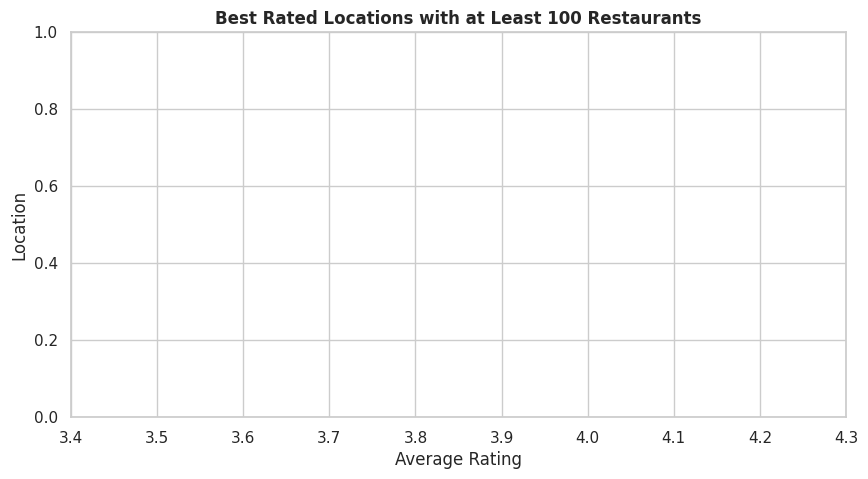

,count,avg_rating
location,,


In [ ]:
location_rating = (
    valid.groupby('location')
    .agg(count=('name', 'count'), avg_rating=('rating', 'mean'))
    .query('count >= 100')
    .sort_values('avg_rating', ascending=False)
    .head(12)
)
sns.barplot(data=location_rating, x='avg_rating', y=location_rating.index, palette='crest')
plt.title('Best Rated Locations with at Least 100 Restaurants')
plt.xlabel('Average Rating')
plt.ylabel('Location')
plt.xlim(3.4, 4.3)
plt.show()
display(location_rating)

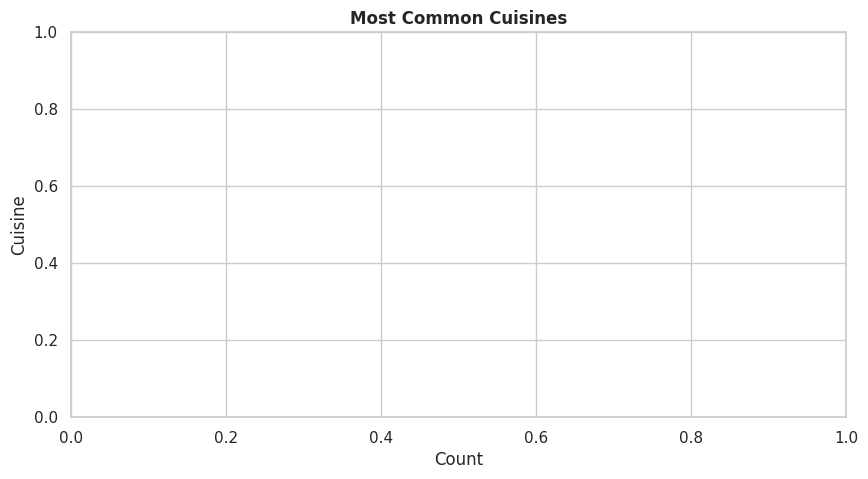

,count,avg_rating
cuisine,,


In [ ]:
cuisine_df = valid[['cuisines', 'rating']].dropna().copy()
cuisine_df['cuisine'] = cuisine_df['cuisines'].str.split(',')
cuisine_df = cuisine_df.explode('cuisine')
cuisine_df['cuisine'] = cuisine_df['cuisine'].str.strip()
cuisine_summary = (
    cuisine_df.groupby('cuisine')
    .agg(count=('rating', 'size'), avg_rating=('rating', 'mean'))
    .query('count >= 100')
)

top_cuisines = cuisine_summary.sort_values('count', ascending=False).head(12)
sns.barplot(data=top_cuisines, x='count', y=top_cuisines.index, palette='rocket')
plt.title('Most Common Cuisines')
plt.xlabel('Count')
plt.ylabel('Cuisine')
plt.show()
display(top_cuisines)

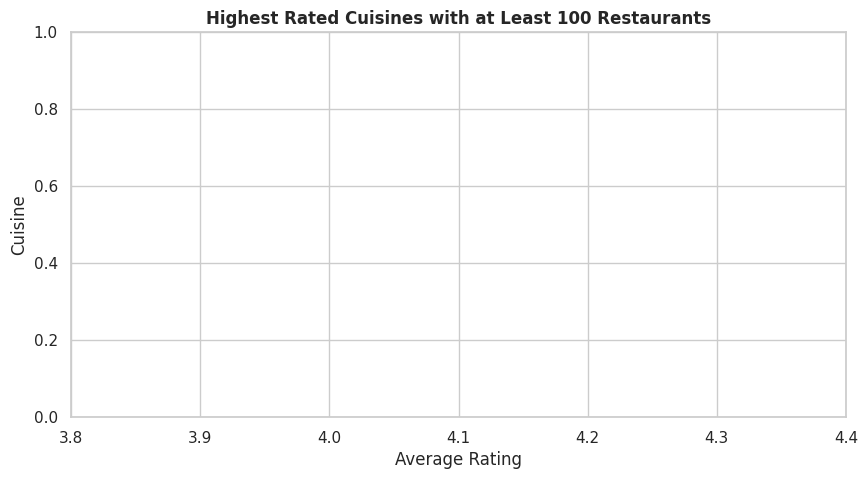

,count,avg_rating
cuisine,,


In [ ]:
best_cuisines = cuisine_summary.sort_values('avg_rating', ascending=False).head(12)
sns.barplot(data=best_cuisines, x='avg_rating', y=best_cuisines.index, palette='flare')
plt.title('Highest Rated Cuisines with at Least 100 Restaurants')
plt.xlabel('Average Rating')
plt.ylabel('Cuisine')
plt.xlim(3.8, 4.4)
plt.show()
display(best_cuisines)

/tmp/ipykernel_1378/4165123252.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=price_rating, x='price_segment', y='avg_rating', palette='magma')


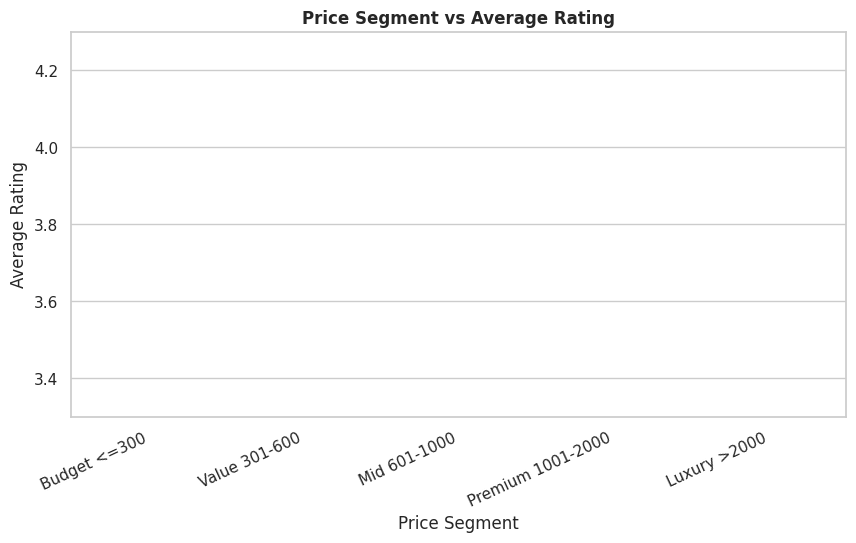

,price_segment,count,avg_rating
0,Budget <=300,0,NaN
1,Value 301-600,0,NaN
2,Mid 601-1000,0,NaN
3,Premium 1001-2000,0,NaN
4,Luxury >2000,0,NaN


In [ ]:
valid['price_segment'] = pd.cut(
    valid['cost_for_two'],
    bins=[0, 300, 600, 1000, 2000, np.inf],
    labels=['Budget <=300', 'Value 301-600', 'Mid 601-1000', 'Premium 1001-2000', 'Luxury >2000']
)
price_rating = valid.groupby('price_segment', observed=False).agg(
    count=('name', 'count'),
    avg_rating=('rating', 'mean')
).reset_index()

sns.barplot(data=price_rating, x='price_segment', y='avg_rating', palette='magma')
plt.title('Price Segment vs Average Rating')
plt.xlabel('Price Segment')
plt.ylabel('Average Rating')
plt.xticks(rotation=25, ha='right')
plt.ylim(3.3, 4.3)
plt.show()
display(price_rating)

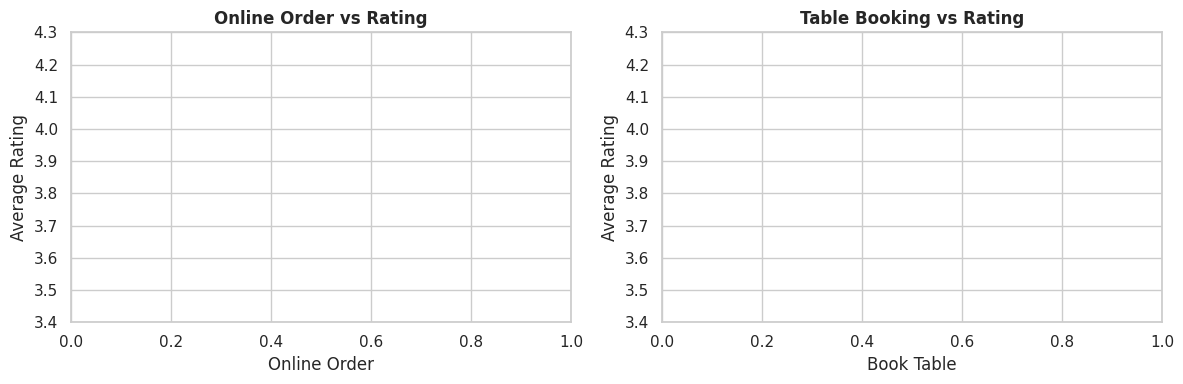

,count,mean
online_order,,


,count,mean
book_table,,


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(data=valid, x='online_order', y='rating', ax=axes[0], palette='Set2')
axes[0].set_title('Online Order vs Rating')
axes[0].set_xlabel('Online Order')
axes[0].set_ylabel('Average Rating')
axes[0].set_ylim(3.4, 4.3)

sns.barplot(data=valid, x='book_table', y='rating', ax=axes[1], palette='Set3')
axes[1].set_title('Table Booking vs Rating')
axes[1].set_xlabel('Book Table')
axes[1].set_ylabel('Average Rating')
axes[1].set_ylim(3.4, 4.3)
plt.tight_layout()
plt.show()

display(valid.groupby('online_order')['rating'].agg(['count', 'mean']))
display(valid.groupby('book_table')['rating'].agg(['count', 'mean']))

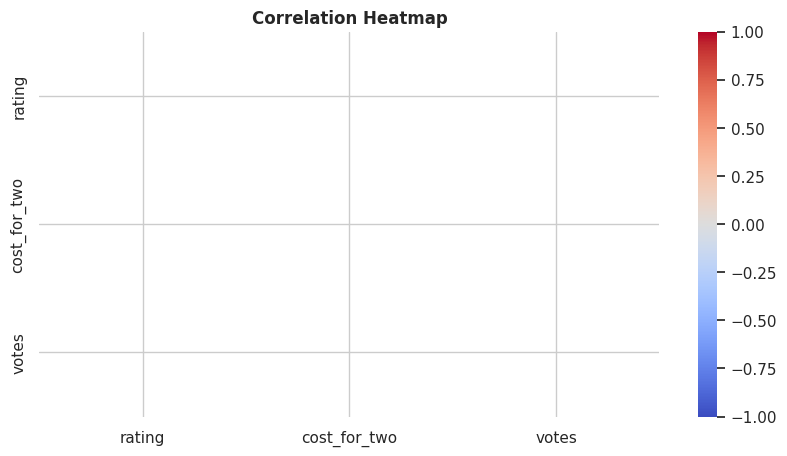

,rating,cost_for_two,votes
rating,NaN,NaN,NaN
cost_for_two,NaN,NaN,NaN
votes,NaN,NaN,NaN


In [ ]:
corr = valid[['rating', 'cost_for_two', 'votes']].corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.show()
display(corr)

In [ ]:
# Word cloud using dish_liked, with cuisines as backup if dish_liked is empty

dish_text = " ".join(
    valid["dish_liked"]
    .dropna()
    .astype(str)
    .str.replace(",", " ")
)

if len(dish_text.strip()) == 0:
    print("dish_liked column is empty, using cuisines instead.")
    dish_text = " ".join(
        valid["cuisines"]
        .dropna()
        .astype(str)
        .str.replace(",", " ")
    )

if len(dish_text.strip()) > 0:
    wordcloud = WordCloud(
        width=1100,
        height=500,
        background_color="white",
        colormap="tab10"
    ).generate(dish_text)

    plt.figure(figsize=(13, 6))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title("Word Cloud of Popular Dishes / Cuisines")
    plt.show()
else:
    print("No text available for word cloud.")

dish_liked column is empty, using cuisines instead.
No text available for word cloud.


## 6. Key Findings

In [ ]:
summary = {
    "Total rows": len(df),
    "Clean valid rows": len(valid),
    "Average rating": round(valid["rating"].mean(), 2) if not valid.empty else np.nan,
    "Average cost for two": round(valid["cost_for_two"].mean(), 0) if not valid.empty else np.nan,
    "Price-rating correlation": round(valid[["cost_for_two", "rating"]].dropna().corr().iloc[0, 1], 3) if not valid[["cost_for_two", "rating"]].dropna().empty else np.nan,
    "Votes-rating correlation": round(valid[["votes", "rating"]].dropna().corr().iloc[0, 1], 3) if not valid[["votes", "rating"]].dropna().empty else np.nan,
}

display(pd.Series(summary, name="Value"))

# Recalculate location and cuisine results safely
location_rating = (
    valid.groupby("location")
    .agg(count=("name", "count"), avg_rating=("rating", "mean"))
    .query("count >= 100")
    .sort_values("avg_rating", ascending=False)
)

cuisine_df = valid[["cuisines", "rating"]].dropna().copy()
cuisine_df["cuisine"] = cuisine_df["cuisines"].str.split(",")
cuisine_df = cuisine_df.explode("cuisine")
cuisine_df["cuisine"] = cuisine_df["cuisine"].str.strip()

cuisine_summary = (
    cuisine_df.groupby("cuisine")
    .agg(count=("rating", "size"), avg_rating=("rating", "mean"))
    .query("count >= 100")
)

# Re-calculate top_cuisines and best_cuisines from the freshly calculated cuisine_summary
top_cuisines = cuisine_summary.sort_values('count', ascending=False).head(12)
best_cuisines = cuisine_summary.sort_values('avg_rating', ascending=False).head(12)


if not valid.empty and not valid["location"].empty:
    top_location = valid["location"].value_counts().idxmax()
else:
    top_location = "N/A (No valid restaurants or locations)"

if not location_rating.empty:
    best_location = location_rating.index[0]
else:
    best_location = "N/A (No highly-rated locations with 100+ restaurants)"

if not top_cuisines.empty:
    most_common_cuisine = top_cuisines.index[0]
else:
    most_common_cuisine = "N/A (No common cuisines with 100+ restaurants)"

if not best_cuisines.empty:
    best_cuisine = best_cuisines.index[0]
else:
    best_cuisine = "N/A (No highly-rated cuisines with 100+ restaurants)"


print("Top location by restaurant count:", top_location)
print("Highest average rated location among locations with 100+ restaurants:", best_location)
print("Most common cuisine:", most_common_cuisine)
print("Highest average rated cuisine among cuisines with 100+ restaurants:", best_cuisine)

,Value
Total rows,56252.000
Clean valid rows,41665.000
Average rating,3.700
Average cost for two,603.000
Price-rating correlation,0.385
Votes-rating correlation,0.434


Top location by restaurant count: BTM
Highest average rated location among locations with 100+ restaurants: Lavelle Road
Most common cuisine: North Indian
Highest average rated cuisine among cuisines with 100+ restaurants: Modern Indian


## 7. Recommendations for Alfido Tech

1. **Focus restaurant discovery on high-performing localities.** Promote premium food hubs like Lavelle Road, St. Marks Road, Church Street, and Koramangala because they show consistently strong ratings.

2. **Use table booking as a quality signal.** Restaurants with table booking have much higher ratings than restaurants without table booking, so this feature should receive weight in recommendations.

3. **Segment restaurants by price.** Premium restaurants usually have higher ratings, while budget restaurants have high volume. Separate budget, mid-range, and premium rankings will produce fairer recommendations.

4. **Promote niche high-rated cuisines.** Modern Indian, Japanese, Mediterranean, European, Korean, and Asian cuisines perform strongly and can be highlighted for users looking for quality dining.

5. **Use popular dishes for tagging and campaigns.** Pasta, burgers, cocktails, pizza, biryani, and coffee appear frequently in liked dishes, so they can improve search, filters, and promotional content.


## 8. Conclusion

The analysis shows that ratings are affected by multiple factors including location, cuisine, price, table booking, and customer engagement. Table booking and premium dining segments are especially strong indicators of higher ratings. A practical recommendation system should combine location, rating, cost segment, cuisine type, table booking availability, and popular dish tags.